<a href="https://colab.research.google.com/github/syedaaikit/data-analyst-portfolio/blob/main/Decodelabs/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning for **DecodeLabs**

In [9]:
import pandas as pd

In [10]:
df = pd.read_excel('Dataset for Data Analytics (1).xlsx')


In [11]:
import matplotlib.pyplot as plt

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [13]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [14]:
df.isnull().sum() / len(df) * 100

,0
OrderID,0.00
Date,0.00
CustomerID,0.00
Product,0.00
Quantity,0.00
UnitPrice,0.00
ShippingAddress,0.00
PaymentMethod,0.00
OrderStatus,0.00
TrackingNumber,0.00


In [15]:
df[df.duplicated()].shape

(0, 14)

In [16]:
df['OrderID'].value_counts()

,count
OrderID,
ORD201183,1
ORD201182,1
ORD201181,1
ORD201180,1
ORD201179,1
...,...
ORD200004,1
ORD200003,1
ORD200002,1


In [17]:
df['CouponCode'] = df['CouponCode'].fillna('None')

In [18]:
df.isnull().sum() / len(df) * 100

,0
OrderID,0.0
Date,0.0
CustomerID,0.0
Product,0.0
Quantity,0.0
UnitPrice,0.0
ShippingAddress,0.0
PaymentMethod,0.0
OrderStatus,0.0
TrackingNumber,0.0


In [21]:
print(df[['Quantity', 'UnitPrice', 'TotalPrice']].describe())

          Quantity    UnitPrice   TotalPrice
count  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750  1053.968300
std       1.407557   197.177146   819.856558
min       1.000000    11.390000    11.390000
25%       2.000000   186.062500   410.520000
50%       3.000000   364.210000   823.615000
75%       4.000000   521.570000  1578.475000
max       5.000000   699.930000  3456.400000


In [30]:
print(df[['Product']].value_counts())

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


In [23]:
median_total = df['TotalPrice'].median()

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
sns.set_theme(style="whitegrid")

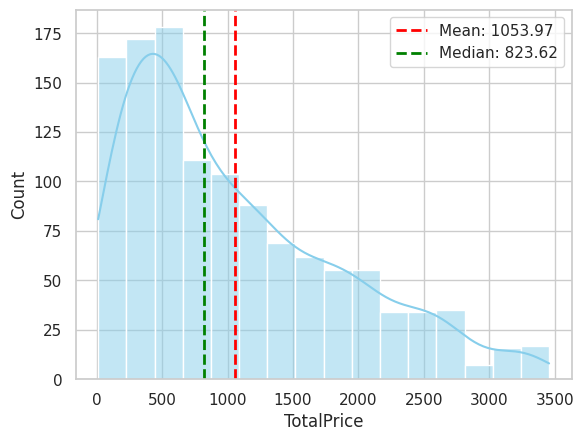

In [35]:
sns.histplot(data=df, x="TotalPrice", kde=True, color="skyblue",)
mean_val = df["TotalPrice"].mean()
median_val = df["TotalPrice"].median()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

--- Total Revenue by Channel ---
ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64


/tmp/ipykernel_20861/3332066528.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_revenue.index, y=channel_revenue.values, palette="Blues_r")


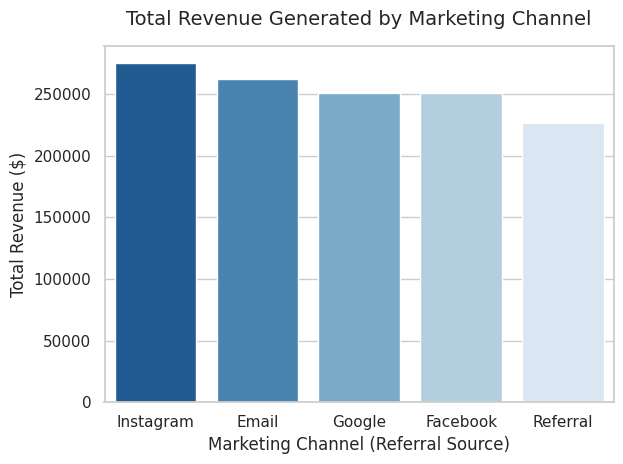

In [36]:
# 1. Calculate total revenue for each channel
channel_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)
print("--- Total Revenue by Channel ---")
print(channel_revenue)

# 2. Plot the results in a bar chart
sns.set_theme(style="whitegrid")
sns.barplot(x=channel_revenue.index, y=channel_revenue.values, palette="Blues_r")

plt.title('Total Revenue Generated by Marketing Channel', fontsize=14, pad=15)
plt.xlabel('Marketing Channel (Referral Source)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_20861/3125392787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_revenue.index, y=status_revenue.values, palette="Reds_r")


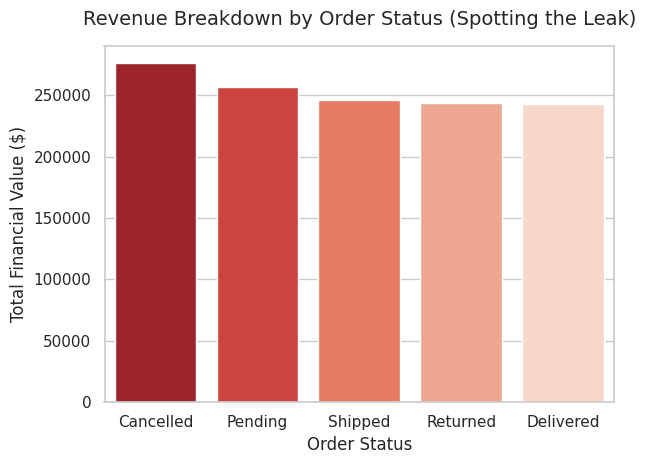

In [37]:
# 1. Group by OrderStatus and sum the total price
status_revenue = df.groupby('OrderStatus')['TotalPrice'].sum().sort_values(ascending=False)

# 2. Set style and plot a diagnostic bar chart
sns.set_theme(style="whitegrid")
sns.barplot(x=status_revenue.index, y=status_revenue.values, palette="Reds_r")

# 3. Add titles and clear axis labels
plt.title('Revenue Breakdown by Order Status (Spotting the Leak)', fontsize=14, pad=15)
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Total Financial Value ($)', fontsize=12)

# 4. Render the chart
plt.tight_layout()
plt.show()

--- Operational Impact by Product ---
OrderStatus  Cancelled  Delivered  Pending  Returned  Shipped
Product                                                      
Chair               45         33       41        28       31
Desk                35         32       38        32       33
Laptop              35         40       30        39       29
Monitor             35         31       29        36       32
Phone               31         38       28        31       28
Printer             35         29       37        38       42
Tablet              34         28       34        43       40

--- Operational Impact by Payment Method ---
OrderStatus    Cancelled  Delivered  Pending  Returned  Shipped
PaymentMethod                                                  
Cash                  49         45       52        57       43
Credit Card           54         43       48        49       40
Debit Card            44         43       55        51       39
Gift Card             50         37   

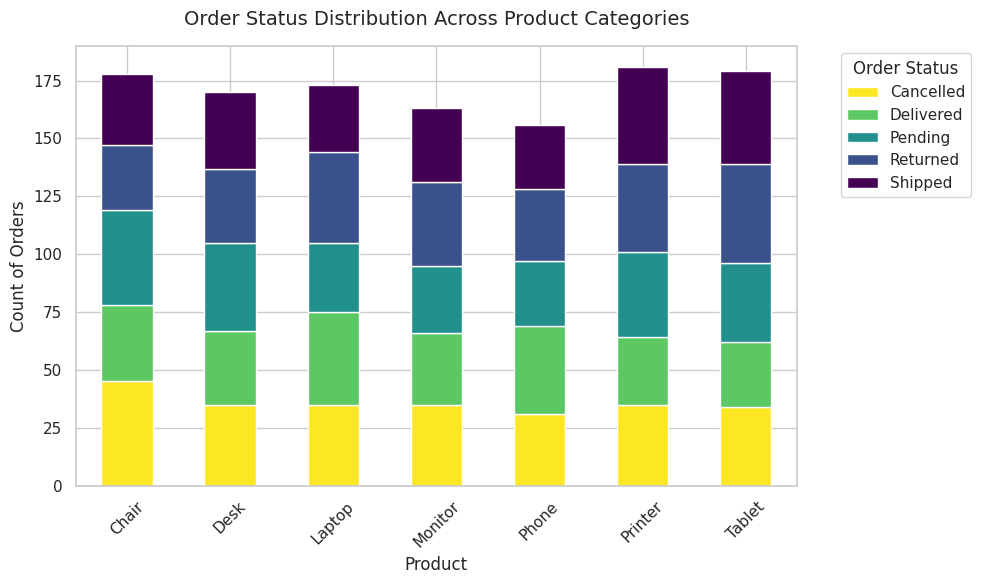

In [38]:
# 1. Look at Order Status by Product Type
print("--- Operational Impact by Product ---")
product_leakage = pd.crosstab(df["Product"], df["OrderStatus"])
print(product_leakage)

# 2. Look at Order Status by Payment Method
print("\n--- Operational Impact by Payment Method ---")
payment_leakage = pd.crosstab(df["PaymentMethod"], df["OrderStatus"])
print(payment_leakage)

# 3. Visualizing the Product Leakage with a Stacked Bar Chart
sns.set_theme(style="whitegrid")
product_leakage.plot(
    kind="bar", stacked=True, figsize=(10, 6), cmap="viridis_r"
)

plt.title(
    "Order Status Distribution Across Product Categories",
    fontsize=14,
    pad=15,
)
plt.xlabel("Product", fontsize=12)
plt.ylabel("Count of Orders", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Order Status", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

1. Distribution Geometry & The Skewness
**bold text**

**ProofPrimary Metrics:**
* Mean (Average Order Value): $1,053.97
Median (Middle/Typical Value): $823.62Data Boundaries: Minimum = $11.39 | Maximum = $3,456.40

**Analytical Diagnostic:** The transaction ecosystem exhibits a prominent Right-Skewed (Positive) Distribution. Because the calculated mean pulls significantly higher than the median ($\Delta = \$230.35$), classical mathematical averages are heavily warped upward by large-ticket, high-volume VIP or bulk corporate orders stretching out to the maximum ceiling of $3,456.40.

**Business Takeaway:** The Median ($823.62) stands as the accurate, robust "center of gravity" for standard customer baskets. Future baseline sales projections and financial runway estimates must rely strictly on the median to protect corporate models from structural overestimation.

**2. Acquisition Funnel Velocity & Gross** PerformanceChannel Financial Contributions (Ranked Highest to Lowest):
Instagram: $275,285.45 (259 orders)
Email: $261,808.55 (250 orders)
Google: $250,441.48 (241 orders)
Facebook: $250,410.90 (228 orders)
Referral (Word-of-Mouth): $226,815.58 (222 orders)
**Analytical Diagnostic:** Instagram and Email campaigns act as the dual core engines of gross revenue, successfully anchoring 42.4% of overall order volume and bringing in a combined gross value of $537,094.00. Standard customer word-of-mouth referrals trail significantly as the weakest acquisition vector.

**Business Takeaway:** Upcoming marketing spend and ad-budget allocation should be funneled primarily into high-converting Instagram acquisition sequences and targeted Email re-engagement streams where conversion velocity is empirically proven.

**3. Critical Operational Revenue **LeakageFulfillment Segments by Total Capital Value:
Cancelled Orders: $276,396.21 (250 orders)Pending Orders: $256,328.15 (237 orders)
Shipped Orders: $246,159.58 (235 orders)
Returned Orders: $243,277.70 (247 orders)Delivered Orders: $242,600.32 (231 orders)**Analytical Diagnostic:** Cross-sectional diagnostic analysis reveals a severe operational fulfillment crisis. The gross financial capital fully trapped or lost within Cancelled and Returned transaction pipelines combined reaches a massive $519,673.91, which drastically eclipses the revenue retained from successfully Delivered orders ($242,600.32). Fulfillments that successfully reach completion represent the absolute smallest segment of the business.

**4. Root-Cause Attrition Granularity
Product Pipeline Vulnerability:**
 Structural failure points fluctuate noticeably across catalog segments. Chairs incur the heaviest baseline upfront cancellations ($45$ units lost), while Tablets represent the maximum post-purchase return friction point ($43$ units rejected).

** Payment Funnel Attrition: **Customer payment choices heavily dictate final delivery success rates. Cash-on-Delivery (COD) transactions are intensely vulnerable to high-volume post-delivery customer rejections ($57$ returns), whereas digital channels like Credit Cards ($54$) and Online Payments ($53$) encounter high instant, pre-shipping buyer-remorse cancellations.

Data-Driven Strategic Directives

**bold text**Optimize Pre-Fulfillment Verification for Digital Channels: **bold text** To curb the high volume of instant Credit Card and Online checkout cancellations, place micro-delays or confirmation steps post-purchase to validate buyer intent.
**De-Risk the COD Pipeline:**
 Address the high return rates associated with Cash-on-Delivery transactions by requiring an automated SMS verification loop or a confirmation call before dispatching high-value physical goods.
** Audit the Tablet Supply Chain:**
  Launch an investigation into the Tablet inventory to determine if high return rates ($43$ units) are being catalyzed by hardware quality control discrepancies, false advertising, or packaging damages during shipping.